In [110]:
import numpy as np

In [59]:
import matplotlib.pyplot as plt
import contextily as ctx

In [60]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
from scipy.stats import entropy

buffer200 = gpd.read_file("/Users/kunjalbhatta/Desktop/tableau/finalBUFFER200json.geojson")
buffer400 = gpd.read_file("/Users/kunjalbhatta/Desktop/tableau/finalBUFFER400.geojson")
buffer800 = gpd.read_file("/Users/kunjalbhatta/Desktop/tableau/buffer800json.geojson")
stations = gpd.read_file("/Users/kunjalbhatta/Desktop/tableau/Underground_Stations.shp")
amenities = pd.read_csv("/Users/kunjalbhatta/Desktop/tableau/amenities_points.csv")

In [61]:
amen_df = amenities.copy()
amen_df["geometry"] = amen_df["geometry"].apply(wkt.loads)

# Convert to GeoDataFrame
amen = gpd.GeoDataFrame(amen_df, geometry="geometry")

amen = amen.set_crs("EPSG:27700")         
amen = amen.to_crs(buffer200.crs)          

# Using TOP_CATEGORY for stable Shannon Index
amen = amen.dropna(subset=["TOP_CATEGORY"])    

### final_shannon as index and final_topcat as top-categories name

In [63]:
# SHANNON DIVERSITY FUNCTION
def shannon_index(gdf):
    """Compute Shannon Diversity Index for a clipped GeoDataFrame."""
    if len(gdf) == 0:
        return 0
    proportions = gdf["TOP_CATEGORY"].value_counts(normalize=True)
    return entropy(proportions)

# FUNCTION TO COMPUTE SHANNON FOR EACH BUFFER
def compute_for_buffer(buffer_gdf, amenities_gdf):
    results = []
    for idx, row in buffer_gdf.iterrows():
        geom = row.geometry
        clipped = amenities_gdf[amenities_gdf.intersects(geom)]
        H = shannon_index(clipped)
        results.append(H)
    return results

In [64]:
# APPLY TO 200m, 400m, 800m BUFFERS

buffer200["H_200"] = compute_for_buffer(buffer200, amen)
buffer400["H_400"] = compute_for_buffer(buffer400, amen)
buffer800["H_800"] = compute_for_buffer(buffer800, amen)

In [65]:
# FINAL SHANNON TABLE - index

final_shannon = pd.DataFrame({
    "station": buffer200["FULL_NAME"],
    "H_200m": buffer200["H_200"],
    "H_400m": buffer400["H_400"],
    "H_800m": buffer800["H_800"]
})

final_shannon

,station,H_200m,H_400m,H_800m
0,St. Paul's station,3.266849,3.438112,3.643347
1,Mile End station,2.669666,3.264333,3.620486
2,Bethnal Green station,3.281953,3.558328,3.705380
3,Leyton station,3.039167,3.448429,3.716820
4,Snaresbrook station,3.153269,3.450540,3.666494
...,...,...,...,...
268,Seven Sisters station,2.799538,3.294378,3.752666
269,Theydon Bois station,0.000000,0.000000,0.000000
270,Kenton station,3.074629,3.521500,3.696571
271,Woodside Park station,2.253858,3.363882,3.800444


In [66]:
# Function: get top N categories inside a geometry
def top_categories(geom, amenities_gdf, N=3):
    clipped = amenities_gdf[amenities_gdf.intersects(geom)]
    
    if clipped.empty:
        return ["None"]
    
    # Count TOP_CATEGORY
    cat_counts = clipped["TOP_CATEGORY"].value_counts()
    
    # Return top N as list
    return cat_counts.head(N).index.tolist()



top_200_list = []
top_400_list = []
top_800_list = []

for idx, row in buffer200.iterrows():
    geom200 = row.geometry
    geom400 = buffer400.loc[idx].geometry
    geom800 = buffer800.loc[idx].geometry

    top_200_list.append(top_categories(geom200, amen))
    top_400_list.append(top_categories(geom400, amen))
    top_800_list.append(top_categories(geom800, amen))


# final table using station name
final_topcats = pd.DataFrame({
    "station": buffer200["FULL_NAME"],      
    "top_200m": top_200_list,
    "top_400m": top_400_list,
    "top_800m": top_800_list
})

final_topcats

,station,top_200m,top_400m,top_800m
0,St. Paul's station,"[Restaurants and Other Eating Places, Accounti...","[Restaurants and Other Eating Places, Accounti...","[Restaurants and Other Eating Places, Accounti..."
1,Mile End station,"[Restaurants and Other Eating Places, Offices ...","[Restaurants and Other Eating Places, Grocery ...","[Restaurants and Other Eating Places, Personal..."
2,Bethnal Green station,"[Restaurants and Other Eating Places, Personal...","[Restaurants and Other Eating Places, Other Am...","[Restaurants and Other Eating Places, Personal..."
3,Leyton station,"[Restaurants and Other Eating Places, Personal...","[Restaurants and Other Eating Places, Personal...","[Restaurants and Other Eating Places, Personal..."
4,Snaresbrook station,"[Restaurants and Other Eating Places, Personal...","[Restaurants and Other Eating Places, Personal...","[Restaurants and Other Eating Places, Personal..."
...,...,...,...,...
268,Seven Sisters station,"[Restaurants and Other Eating Places, Personal...","[Restaurants and Other Eating Places, Personal...","[Restaurants and Other Eating Places, Personal..."
269,Theydon Bois station,[None],[None],[None]
270,Kenton station,"[Restaurants and Other Eating Places, Personal...","[Restaurants and Other Eating Places, Accounti...","[Restaurants and Other Eating Places, Accounti..."
271,Woodside Park station,"[Investigation and Security Services, Nursing ...","[Accounting, Tax Preparation, Bookkeeping, and...","[Restaurants and Other Eating Places, Personal..."


# shannon index visualize

In [68]:
final_topcats["cat_200m"] = final_topcats["top_200m"].apply(lambda x: x[0] if isinstance(x, list) and len(x)>0 else None)
final_topcats["cat_400m"] = final_topcats["top_400m"].apply(lambda x: x[0] if isinstance(x, list) and len(x)>0 else None)
final_topcats["cat_800m"] = final_topcats["top_800m"].apply(lambda x: x[0] if isinstance(x, list) and len(x)>0 else None)


In [69]:
final_topcats[["station", "cat_200m", "cat_400m", "cat_800m"]].head()

,station,cat_200m,cat_400m,cat_800m
0,St. Paul's station,Restaurants and Other Eating Places,Restaurants and Other Eating Places,Restaurants and Other Eating Places
1,Mile End station,Restaurants and Other Eating Places,Restaurants and Other Eating Places,Restaurants and Other Eating Places
2,Bethnal Green station,Restaurants and Other Eating Places,Restaurants and Other Eating Places,Restaurants and Other Eating Places
3,Leyton station,Restaurants and Other Eating Places,Restaurants and Other Eating Places,Restaurants and Other Eating Places
4,Snaresbrook station,Restaurants and Other Eating Places,Restaurants and Other Eating Places,Restaurants and Other Eating Places


In [70]:
merged = final_shannon.merge(final_topcats, on="station", how="left")

In [71]:
print("Mean Shannon Diversity Index")
print(f"200m: {merged['H_200m'].mean():.3f}")
print(f"400m: {merged['H_400m'].mean():.3f}")
print(f"800m: {merged['H_800m'].mean():.3f}")


Mean Shannon Diversity Index
200m: 2.920
400m: 3.271
800m: 3.495


In [142]:
cat_counts_200 = merged["cat_200m"].value_counts()
print("Dominant Category (200m):")
print(cat_counts_200.to_string())


Dominant Category (200m):
cat_200m
Restaurants and Other Eating Places                               218
None                                                               14
Taxi and Limousine Service                                          8
Personal Care Services                                              6
Elementary and Secondary Schools                                    3
Offices of Physicians                                               3
Travel Arrangement and Reservation Services                         2
Other Amusement and Recreation Industries                           2
Clothing Stores                                                     2
Accounting, Tax Preparation, Bookkeeping, and Payroll Services      2
Social Advocacy Organizations                                       2
Advertising, Public Relations, and Related Services                 2
Traveler Accommodation                                              1
Warehousing and Storage                                

In [73]:
cat_counts_400 = merged["cat_400m"].value_counts()
print("Dominant Category (400m):")
print(cat_counts_400.to_string())

Dominant Category (400m):
cat_400m
Restaurants and Other Eating Places                               236
None                                                               14
Personal Care Services                                              6
Accounting, Tax Preparation, Bookkeeping, and Payroll Services      4
Offices of Physicians                                               3
Clothing Stores                                                     2
Jewelry, Luggage, and Leather Goods Stores                          2
Other Amusement and Recreation Industries                           1
Offices of Other Health Practitioners                               1
Printing and Related Support Activities                             1
Warehousing and Storage                                             1
Taxi and Limousine Service                                          1
Elementary and Secondary Schools                                    1
Activities Related to Real Estate                      

In [74]:
cat_counts_800 = merged["cat_800m"].value_counts()
print("Dominant Category (800m):")
print(cat_counts_800.to_string())

Dominant Category (800m):
cat_800m
Restaurants and Other Eating Places                               251
None                                                               14
Offices of Physicians                                               3
Personal Care Services                                              2
Accounting, Tax Preparation, Bookkeeping, and Payroll Services      1
Other Schools and Instruction                                       1
Computer Systems Design and Related Services                        1
Warehousing and Storage                                             1
Scheduled Air Transportation                                        1


In [98]:
cat_counts_200 = cat_counts_200[cat_counts_200.index != "None"]
cat_counts_400 = cat_counts_400[cat_counts_400.index != "None"]
cat_counts_800 = cat_counts_800[cat_counts_800.index != "None"]


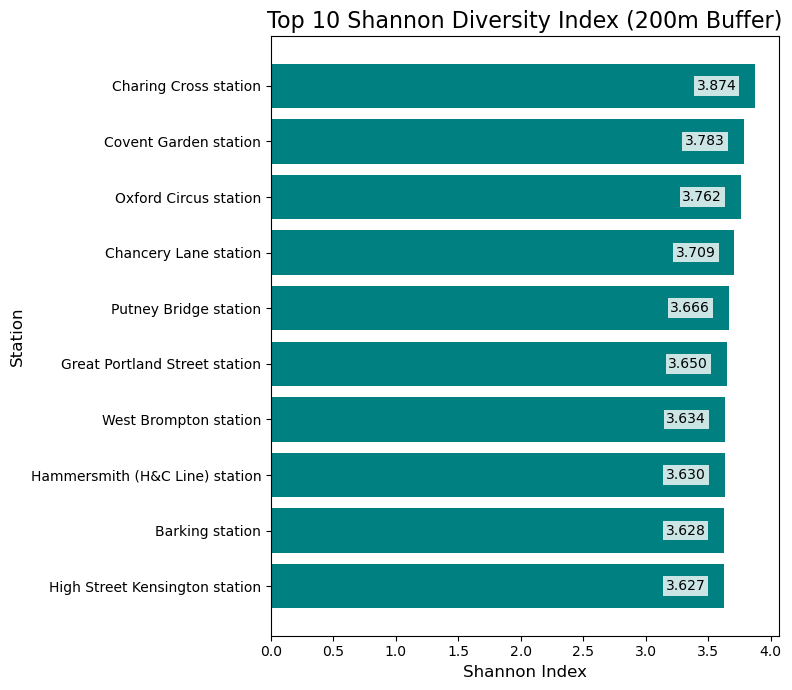

In [138]:
df_top10_200 = final_shannon.sort_values("H_200m", ascending=False).head(10)

plt.figure(figsize=(8,7))
bars = plt.barh(df_top10_200["station"], df_top10_200["H_200m"], color="teal")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width - 0.15,                              
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        ha="right",
        fontsize=10,
        color="black",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2)
    )

plt.title("Top 10 Shannon Diversity Index (200m Buffer)", fontsize=16)
plt.xlabel("Shannon Index", fontsize=12)
plt.ylabel("Station", fontsize=12)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


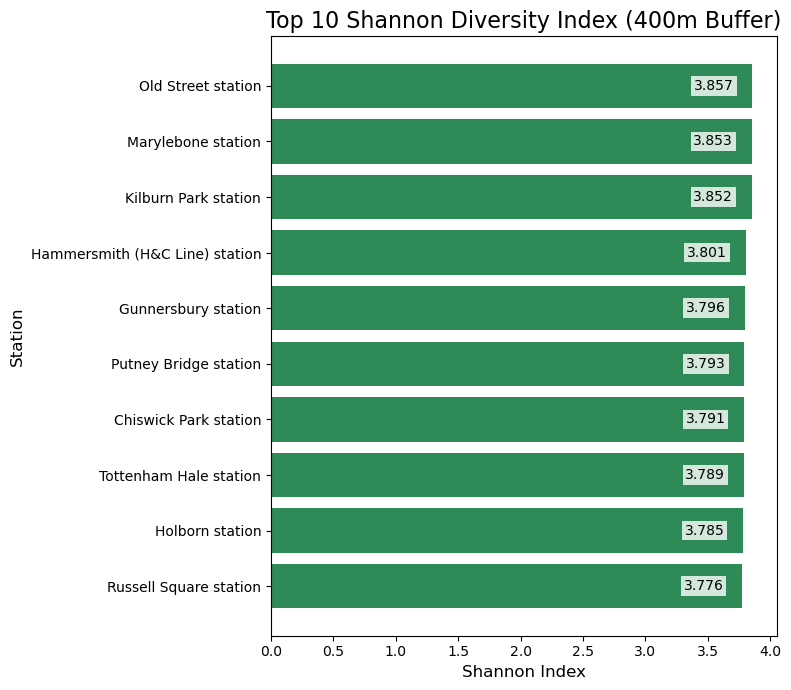

In [140]:
df_top10_400 = final_shannon.sort_values("H_400m", ascending=False).head(10)

plt.figure(figsize=(8,7))
bars = plt.barh(df_top10_400["station"], df_top10_400["H_400m"], color="seagreen")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width - 0.15,                              
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        ha="right",
        fontsize=10,
        color="black",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2)
    )

plt.title("Top 10 Shannon Diversity Index (400m Buffer)", fontsize=16)
plt.xlabel("Shannon Index", fontsize=12)
plt.ylabel("Station", fontsize=12)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


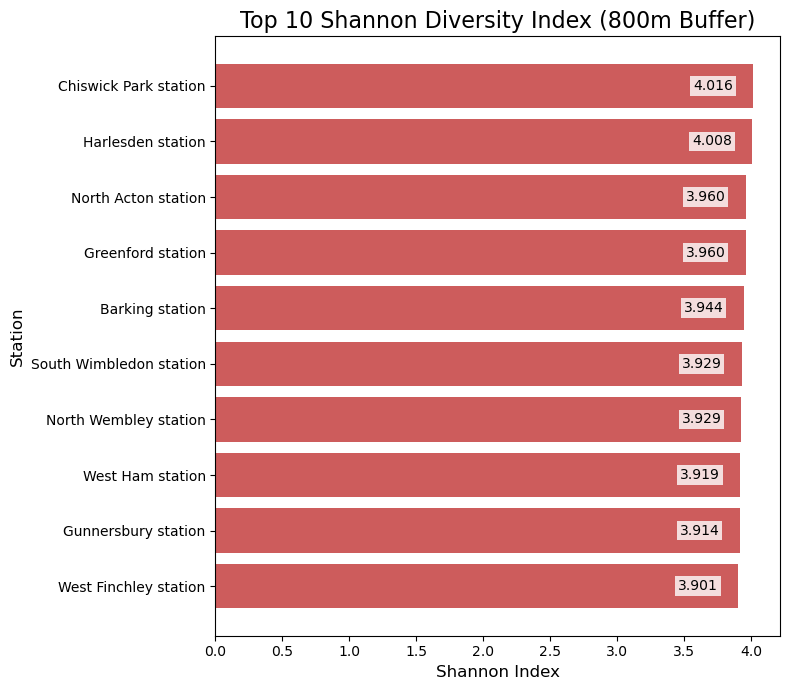

In [136]:
df_top10_800 = final_shannon.sort_values("H_800m", ascending=False).head(10)

plt.figure(figsize=(8,7))
bars = plt.barh(df_top10_800["station"], df_top10_800["H_800m"], color="indianred")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width - 0.15,                               
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        ha="right",
        fontsize=10,
        color="black",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2)
    )

plt.title("Top 10 Shannon Diversity Index (800m Buffer)", fontsize=16)
plt.xlabel("Shannon Index", fontsize=12)
plt.ylabel("Station", fontsize=12)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
